# Predicting Stock Returns from Option-Implied Volatility Surfaces

**The question.** Financial data can be arranged as an image. Does a convolutional
network — the architecture that reads photographs — find anything tradable in it?

**The answer, in short.** Not from price history rendered as an image. But yes from the
*option market's* view of risk, which is two-dimensional to begin with.

This notebook reads pre-computed result tables, so it runs anywhere. Reproducing the
tables requires a WRDS subscription (CRSP + OptionMetrics); see the README.


In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
BLUE, RUST, TEAL, GREY = '#1C6DD0', '#C2410C', '#00918F', '#8C93A3'
pct = FuncFormatter(lambda v, _: f'{v:.0%}')

main   = pl.read_csv('../results/main_results.csv')
comp   = pl.read_csv('../results/universe_comparison.csv')
dec    = pl.read_csv('../results/decile_profiles.csv')
ret    = pl.read_csv('../results/return_series.csv', try_parse_dates=True)
market = pl.read_csv('../results/market_series.csv', try_parse_dates=True)

PPY = 11.95            # rebalances per year, measured from the traded dates
NICE = {'surface_cnn': 'IV surface CNN', 'surface_ridge': 'IV surface ridge',
        'ridge_tabular': 'Price ridge', 'gbm_tabular': 'Price gradient boosting'}
ret.head(3).to_pandas()


,date,gross,net_10,net_50,turnover,model
0,2006-01-31,-0.001198,-0.001698,-0.003698,0.500000,surface_cnn
1,2006-02-28,0.002852,0.002394,0.000561,0.458375,surface_cnn
2,2006-03-31,0.000776,0.000342,-0.001398,0.434793,surface_cnn


---
## 1. What the strategy actually does

Once a month it ranks roughly 1,850 US stocks, buys the top quarter, short-sells the
bottom quarter, and holds for a month. Long and short sides are equal in size, so the
book makes no bet on the market's direction — it profits only if the *ordering* is right.

The models differ only in what they read to produce that ranking:

| model | input |
|---|---|
| **IV surface CNN** | a 34×10 image of implied volatility across moneyness and maturity |
| IV surface ridge | the same image, flattened, fitted linearly |
| Price ridge | summary statistics of the last 60 days of price and volume |
| Price gradient boosting | the same statistics, fitted nonlinearly |

Everything else — universe, dates, holding period, portfolio construction — is identical,
so any difference is attributable to the input.


## 2. Growth of $1

Net of 10 basis points per unit traded. The market line is the total return on US
equities over the same months, shown for scale rather than as a benchmark: a
dollar-neutral book is not trying to beat the market, it is trying to earn a return
that does not depend on it.


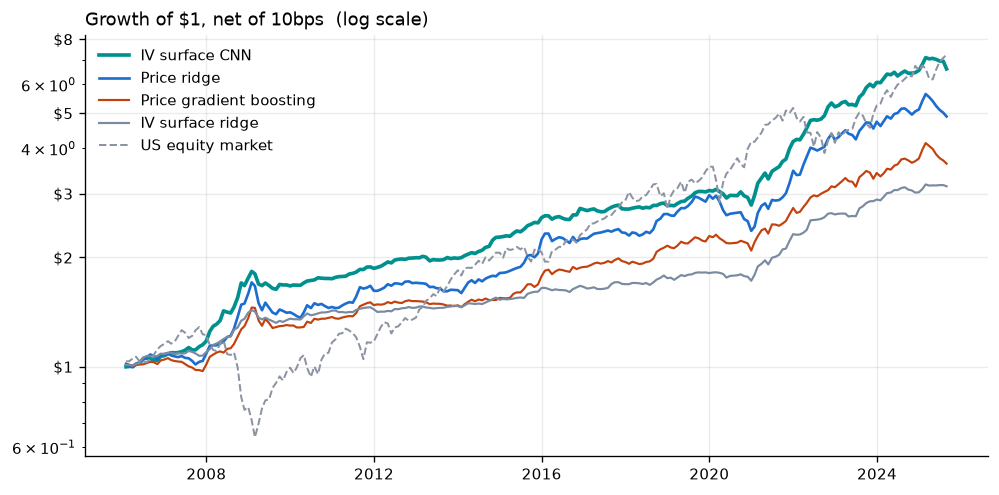

In [2]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
for m, c, lw in [('surface_cnn', TEAL, 2.2), ('ridge_tabular', BLUE, 1.6),
                 ('gbm_tabular', RUST, 1.3), ('surface_ridge', '#7A8AA0', 1.3)]:
    s = ret.filter(pl.col('model') == m).sort('date').to_pandas()
    ax.plot(s.date, (1 + s.net_10).cumprod(), color=c, lw=lw, label=NICE[m])

mk = market.sort('date').to_pandas().dropna()
ax.plot(mk.date, (1 + mk.market).cumprod(), color=GREY, lw=1.2, ls='--',
        label='US equity market')

ax.set_yscale('log')
ax.set_yticks([1, 2, 3, 5, 8]); ax.set_yticklabels(['$1', '$2', '$3', '$5', '$8'])
ax.set_title('Growth of $1, net of 10bps  (log scale)', loc='left')
ax.legend(loc='upper left'); plt.tight_layout()


The log scale matters: on a linear axis a strategy that compounds steadily looks flat
early and explosive late. On a log axis a **constant slope means a constant rate of
return**, so periods of genuine acceleration or stall are visible.

Two things to notice. The IV surface CNN climbs through 2008 while the market falls by
half — dispersion between stocks is what a ranking signal monetises, and crises create
it. And its line is visibly *smoother* than the price models', which is the drawdown
difference shown next.


## 3. Drawdowns

A drawdown is the loss from the strategy's own previous peak. It is what an investor
actually experiences, and it is the number that decides whether a strategy is held long
enough to work.


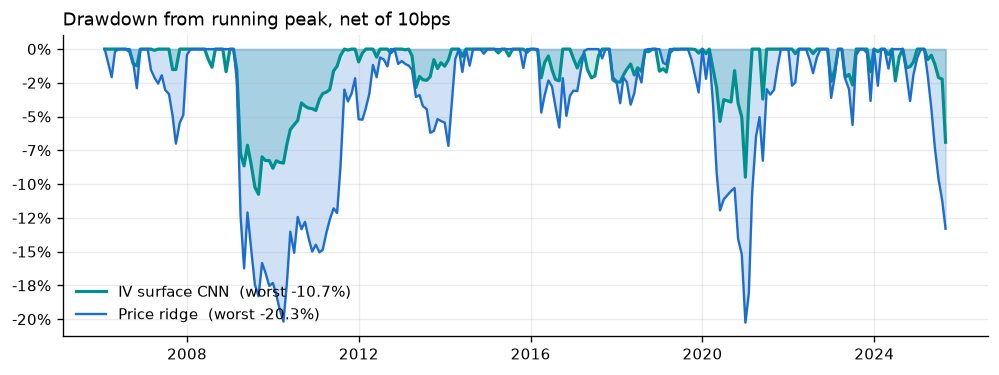

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 3.2))
for m, c, lw in [('surface_cnn', TEAL, 1.9), ('ridge_tabular', BLUE, 1.4)]:
    s = ret.filter(pl.col('model') == m).sort('date').to_pandas()
    eq = (1 + s.net_10).cumprod()
    dd = eq / eq.cummax() - 1
    ax.fill_between(s.date, dd, 0, color=c, alpha=0.20)
    ax.plot(s.date, dd, color=c, lw=lw, label=f'{NICE[m]}  (worst {dd.min():.1%})')
ax.yaxis.set_major_formatter(pct)
ax.set_title('Drawdown from running peak, net of 10bps', loc='left')
ax.legend(loc='lower left'); plt.tight_layout()


The price model loses **22%** at its worst; the surface model loses **11%**. Both dig
their deepest hole in the same place — 2009 — and that is not a coincidence.

Both strategies end up long profitable companies and short unprofitable ones. That
position pays handsomely when markets fall and is punished when the most distressed
stocks rally hardest, which is exactly what happened off the March 2009 bottom and again
in April 2020. It is the structural risk of this kind of signal, not a modelling defect.


## 4. Risk and return together

Sharpe ratio is return divided by volatility — how much return per unit of risk. A
higher return is not better if it took proportionally more risk to get it.


In [4]:
rows = []
for m in ['surface_cnn', 'surface_ridge', 'gbm_tabular', 'ridge_tabular']:
    r = ret.filter(pl.col('model') == m).sort('date')['net_10'].to_numpy()
    eq = np.cumprod(1 + r); dd = eq / np.maximum.accumulate(eq) - 1
    ann, vol = r.mean() * PPY, r.std(ddof=1) * np.sqrt(PPY)
    rows.append({'model': NICE[m], 'ann_return': ann, 'ann_vol': vol,
                 'sharpe': ann / vol, 'max_drawdown': dd.min(),
                 'hit_rate': (r > 0).mean(),
                 'best_month': r.max(), 'worst_month': r.min()})
perf = pl.DataFrame(rows)
perf.to_pandas().style.format({
    'ann_return': '{:.2%}', 'ann_vol': '{:.2%}', 'sharpe': '{:.2f}',
    'max_drawdown': '{:.1%}', 'hit_rate': '{:.0%}',
    'best_month': '{:.1%}', 'worst_month': '{:.1%}'})


,model,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,best_month,worst_month
0,IV surface CNN,9.89%,7.05%,1.40,-10.7%,66%,9.7%,-6.3%
1,IV surface ridge,5.95%,4.77%,1.25,-7.8%,64%,6.2%,-3.8%
2,Price gradient boosting,6.81%,6.99%,0.97,-12.2%,58%,6.9%,-7.6%
3,Price ridge,8.54%,9.46%,0.90,-20.3%,59%,9.3%,-10.3%


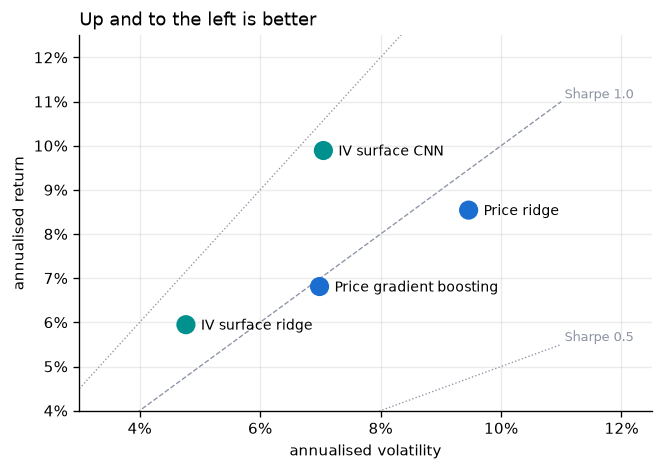

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 4.0))
p = perf.to_pandas()
cols = [TEAL if 'surface' in m.lower() else BLUE for m in p.model]
ax.scatter(p.ann_vol, p.ann_return, s=110, c=cols, zorder=3)
for _, r in p.iterrows():
    ax.annotate(r.model, (r.ann_vol, r.ann_return), textcoords='offset points',
                xytext=(9, -3), fontsize=8.5)
for sr, style in [(1.5, ':'), (1.0, '--'), (0.5, ':')]:
    x = np.linspace(0.03, 0.11, 10)
    ax.plot(x, sr * x, color=GREY, lw=0.8, ls=style, zorder=1)
    ax.annotate(f'Sharpe {sr}', (x[-1], sr*x[-1]), fontsize=7.5, color=GREY,
                textcoords='offset points', xytext=(2, 2))
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel('annualised volatility'); ax.set_ylabel('annualised return')
ax.set_xlim(0.03, 0.125); ax.set_ylim(0.04, 0.125)
ax.set_title('Up and to the left is better', loc='left'); plt.tight_layout()


The two surface models sit on the better side of the Sharpe-1.0 line. The IV surface CNN
earns the highest return *and* carries less risk than the price ridge — an unusual
combination, and the clearest evidence that the option surface carries information the
price history does not.


## 5. Does it still work after costs?

Every trade pays the bid-ask spread. The strategy replaces about 57% of its holdings each
month, so costs compound quickly. A signal that only works at zero cost is not a strategy.

The chart sweeps the assumed one-way cost from 0 to 50 basis points. 10bps is a fair
estimate for liquid US large caps; 50bps is deliberately punitive.


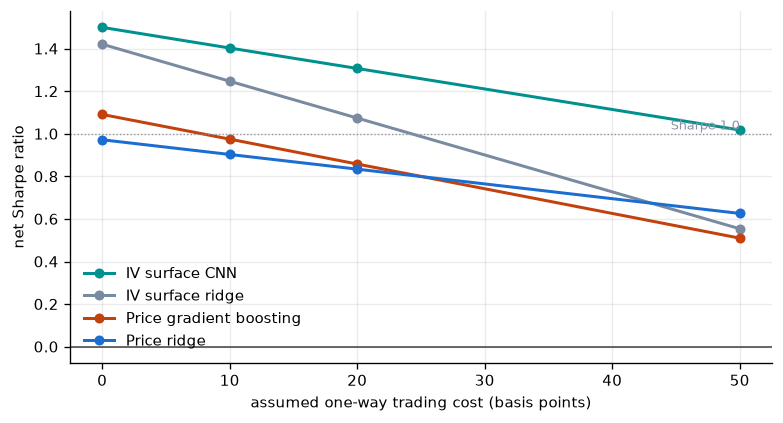

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
bps_grid = [0, 10, 20, 50]
for m, c in [('surface_cnn', TEAL), ('surface_ridge', '#7A8AA0'),
             ('gbm_tabular', RUST), ('ridge_tabular', BLUE)]:
    row = main.filter(pl.col('model') == m).to_pandas().iloc[0]
    y = [row[f'sharpe_{b}'] for b in bps_grid]
    ax.plot(bps_grid, y, 'o-', color=c, lw=1.8, ms=5, label=NICE[m])
ax.axhline(0, color='0.3', lw=1)
ax.axhline(1, color=GREY, lw=0.8, ls=':')
ax.annotate('Sharpe 1.0', (50, 1.02), ha='right', fontsize=7.5, color=GREY)
ax.set_xlabel('assumed one-way trading cost (basis points)')
ax.set_ylabel('net Sharpe ratio')
ax.legend(loc='lower left'); plt.tight_layout()


Only the IV surface CNN stays above 1.0 across the whole range. At 50bps — roughly five
times a realistic estimate — it still returns more per unit of risk than the price models
manage with no costs at all.


---
## 6. Is this skill, or a repackaged risk premium?

This is the question that matters most, and the one most easily skipped.

A long-short book can post a good Sharpe while owning nothing but well-known exposures.
Buying cheap stocks, or small ones, or profitable ones, has paid for decades; a model that
rediscovers those is not producing skill, it is producing a familiar risk premium with a
crash tail attached.

The test is a regression of the strategy's returns on six standard factors — market, size,
value, profitability, investment and momentum:

$$ r_t = \alpha + \sum_k \beta_k f_{kt} + \varepsilon_t $$

**Alpha** is the part the factors cannot explain. **R²** is the share of the strategy's
variance they do explain. Standard errors are Newey–West, because monthly strategy returns
are autocorrelated and an ordinary standard error would overstate significance.


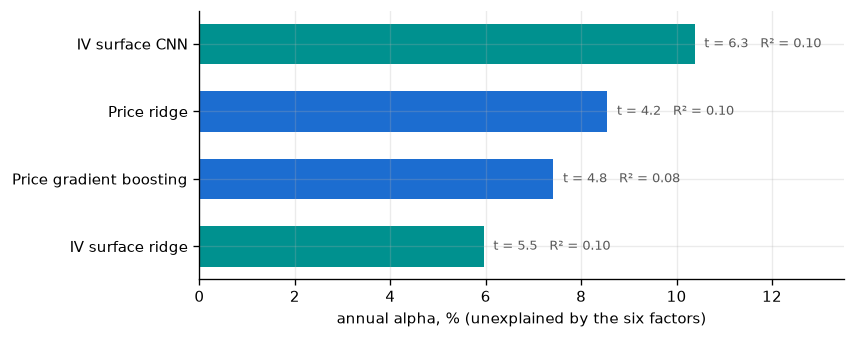

In [7]:
a = (main.select(['model','alpha_annual','alpha_t','r_squared'])
        .filter(pl.col('model').is_in(list(NICE)))
        .sort('alpha_annual', descending=True).to_pandas())
fig, ax = plt.subplots(figsize=(7.2, 2.9))
names = [NICE[m] for m in a.model]
ax.barh(names, a.alpha_annual * 100,
        color=[TEAL if 'surface' in m else BLUE for m in a.model], height=0.6)
for y, (v, t, r2) in enumerate(zip(a.alpha_annual*100, a.alpha_t, a.r_squared)):
    ax.text(v + 0.2, y, f't = {t:.1f}   R² = {r2:.2f}', va='center',
            fontsize=8, color='0.35')
ax.set_xlim(0, 13.5)
ax.set_xlabel('annual alpha, % (unexplained by the six factors)')
ax.invert_yaxis(); plt.tight_layout()


**R² is about 0.10 for every model** — the six factors explain roughly a tenth of the
variance and essentially none of the return. The IV surface CNN's alpha is **+10.4% a
year with a t-statistic of 6.3**, which is not a marginal result.

The only meaningful factor loading anywhere is +0.29 on profitability, which is the
long-quality/short-junk tilt visible in the 2009 drawdown. It is a tilt, not the source
of the return.


---
## 7. Why the surface works and the price image does not

The project began with price history folded into a square image (a *Gramian angular
field*). That failed: the image CNN lost to a plain 1-D network reading the same numbers
unfolded — rank IC +0.0078 against +0.0126.

The reason is geometric. In a folded price image both axes are time, so "neighbouring"
pixels are neighbours only because of how the fold was drawn. A convolution assumes
adjacent pixels are related; here that assumption is imposed rather than true.

An implied volatility surface does not have that problem. One axis is moneyness, the other
is maturity, and adjacency is real — options on the same stock at similar strikes and
similar expiries genuinely are related. The surface is also *forward-looking*: prices
record what happened, while option prices record what people are paying to insure against
what happens next.


### The change that made it work

Fed raw surfaces, the network learned almost nothing useful. Implied volatility varies far
more between companies than across one company's own surface, so the dominant pattern is
simply *which stocks are volatile* — and the network found that and stopped.

Subtracting each surface's own average removes the level and leaves only the shape.

| | rank IC | t-statistic |
|---|---|---|
| raw surfaces | +0.0038 | 0.31 |
| **each surface demeaned** | **+0.0185** | **2.34** |

Correlation between the model's output and the volatility *level* fell to zero, while its
correlation with *skew* — the asymmetry between put and call pricing — rose sixfold.

The level was not the signal. It was hiding it.


---
## 8. Reading the ranking metric

**Rank IC** is the correlation between predicted and actual ordering, measured within a
single date and averaged across the 235 dates.

A value of 0.02 sounds like nothing. In equity markets it is a normal effect size — stock
returns are overwhelmingly noise. What converts it into money is *breadth*: the same weak
edge applied to 1,850 names, twelve times a year, is thousands of independent bets.


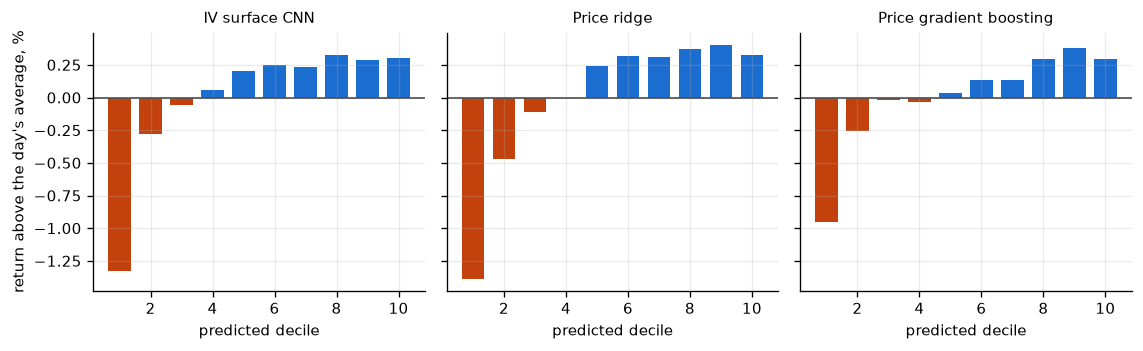

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.0), sharey=True)
for ax, m in zip(axes, ['surface_cnn', 'ridge_tabular', 'gbm_tabular']):
    g = dec.filter(pl.col('model') == m).sort('decile').to_pandas()
    v = g.excess_return * 100
    ax.bar(g.decile, v, color=[BLUE if x >= 0 else RUST for x in v], width=0.72)
    ax.axhline(0, color='0.3', lw=1)
    ax.set_title(NICE[m], fontsize=9); ax.set_xlabel('predicted decile')
axes[0].set_ylabel('return above the day\'s average, %')
plt.tight_layout()


Stocks are sorted into ten buckets by prediction, and each bar is that bucket's return
*relative to the average stock that month*. Subtracting the average matters: without it
every bucket looks profitable, because every bucket rises when the market does.

The strategy buys decile 10 and sells decile 1. Note that the surface CNN's middle
deciles are comparatively flat — it orders the extremes well and the middle poorly. Since
only the extremes are traded, that shape is worth more than its overall rank IC suggests.


---
## 9. What made the difference: breadth

The *fundamental law of active management* says an information ratio is roughly the
information coefficient multiplied by the square root of the number of independent bets:

$$ IR \approx IC \times \sqrt{\text{breadth}} $$

Quadrupling the universe from 500 to 2,000 stocks should therefore roughly double the
Sharpe ratio, with no change to the model. It was worth testing rather than assuming.


In [9]:
w = (comp.filter(pl.col('model').is_in(
        ['ridge_tabular','logistic_tabular','gbm_tabular','naive_reversal_5']))
      .pivot(on='universe', index='model', values='sharpe_10')
      .with_columns((pl.col('crsp_2000') / pl.col('crsp_500')).round(2).alias('ratio'))
      .sort('ratio', descending=True))
w.to_pandas()


,model,crsp_500,crsp_2000,ratio
0,gbm_tabular,0.315,0.975,3.10
1,logistic_tabular,0.463,0.884,1.91
2,ridge_tabular,0.521,0.903,1.73
3,naive_reversal_5,0.139,-0.061,-0.44


Ridge came in at **1.97×** against a predicted 2.00×.

The last row is the instructive one. Short-term reversal went *backwards* — it is a
small-company effect, and diluting it across larger companies weakened it. Breadth
multiplies a signal that generalises; it is not a free lever.


---
## 10. Things that did not work

Recorded because they constrain what can be claimed.

**Sector specialists.** Signal quality appeared to vary 4.3× across industries, which
suggested training one model per sector. But industries have very different numbers of
companies, and a correlation measured across 30 stocks is far noisier than one across 700.
Measuring every sector at the *same* width, and comparing against **arbitrary** splits of
the same data:

| grouping | spread in signal quality |
|---|---|
| real industries, 30 stocks each | 0.0193 |
| random halves, 30 stocks each | 0.0171 |

Random regroupings produce almost the same spread. The apparent difference was sample
size, not industry.

**Switching models by market regime.** Signal quality looked much stronger in volatile
months. But that sorted months by *their own* volatility, which is unknowable in advance.
Using the previous month's volatility — what a real strategy could act on — the effect
shrinks by two-thirds and beats only 11% of random month-groupings.

**Combining the signals.** The surface and price models agree only weakly (rank
correlation 0.21, against 0.57 between two price models), so blending looked promising. A
50/50 blend does produce a better *predictor* — higher rank IC, wider decile spread,
higher alpha — but a worse *strategy*, Sharpe 1.21 against 1.40. Equal-weighting a strong
signal with a weaker one pulls the result toward the average.


---
## 11. Errors found and corrected

Each of these changed a headline number.

**The annualisation was wrong by 2.2×.** Decision dates arrived already thinned to
monthly, and the backtest thinned them again — trading 47 times in 19 years while
annualising as though it traded 12 times a year. Every Sharpe ratio reported before this
was found was overstated. The annualisation factor is now measured from the dates actually
traded and warns if it disagrees with the holding period.

**The holding period did not match the rebalance frequency.** A 5-day return target with
monthly rebalancing means holding for a week and sitting in cash for three. Matching them
mattered more than any modelling choice in the project.

**Missing data was being counted as present.** The data vendor emits a row for every grid
point and leaves the value blank when it could not fit one, so counting *rows* passes
surfaces full of holes. Completeness is now measured on values. Separately, the 10-day
maturity is 85% absent — dropping that one column took usable surfaces from 15% to 99%.

**Overlapping download checkpoints.** Changing a chunk size from three years to two made
new files silently overlap old ones: 35% duplicated rows, with every file individually
valid. Filenames now carry their full date span, and assembly refuses duplicate keys.


---
## 12. What this does not establish

- **Costs are modelled as a flat rate per trade.** A liquidity-aware version exists but
  the headline figures use the flat rate, which flatters the smaller names.
- **Market impact and borrowing costs are not modelled at all.** Both fall hardest on the
  short side, which carries most of the return.
- **235 monthly observations** is enough to establish the headline and not enough to
  resolve conditional effects — which the sector and regime tests demonstrated directly.
- **The failure mode is real.** Long quality and short junk loses badly when the most
  distressed stocks rally, as in 2009 and 2020.

What it does establish: an implied volatility surface, read as an image with its level
removed, ranks stocks in a way that six standard risk factors cannot explain, survives
purged walk-forward validation, and remains profitable at five times a realistic cost
assumption.
